### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 1
### Due: Friday, Oct 3rd at 11:59pm Pacific
---

## Handing in Homework

You had the opportunity to practice your git and GitHub skills by submitting HW0 via GitHub. You will need to repeat the process for every homework assigment going forward. Please make sure a copy of the completed assignment is placed in your repos "my_work" directory and pushed to GitHub. Please label files _starting_ with the appropriate hw number. This week's will be `hw1_YOUR_NAME.ipynb`. In addition, I want another document which only has the answers to the questions asked in this HW assignment, along with any figures that you deem appropriate to make yourself understood. Please restate the question where appropriate. Code files will be checked for completeness **only**. I will only consider the answers in the separate `pdf` for grading your understanding of the questions.

**WARNING for devcontainer users:** If you are using the **devcontainer** via `VSCode`, then you will want to make a separate working folder directly in your fork of the class repo and work on your assignment by either _copying_ a notebook in there or opening a new one in that folder. The reason is that the _repo_ has the devcontainer instructions and when you open `VSCode` it recognizes this and starts up the devcontainer.  

## Problem 1



Consider a family with two children. Assume that the probability of females and males being born is equal, i.e. $p(F)=0.5$ and $p(M)=0.5$. Remember that "given" means your calculation is conditioned on some already fixed data or outcome. 

1) What is the probability of one male and one female **GIVEN** that the first child is male. 

2) What is the probability of two females **GIVEN** that at least one child is female.

3) What is the probability of two females **GIVEN** that the older child is female.

You will find it easiest to answer these questions by sketching a "tree diagram" to visualize the options for the oldest child, and the branching options for the youngest child. 

Either write your solution as Markdown/Latex below, or paste in a scanned image of your handwritten solution.

### Solution

1) *(To get you started)* If the first child is male, then the only unknown is the sex of the second child. We want the second child to be female, which has a probability of 0.5. Thus, $p(F,M |C_1=M) = 0.5$. 

2) $p(F,F|C_x = F)$. The unknown probability is that of the "second" child that is unknown and probability of female is 1/2 = 0.5.

3) $p(F,F| C_1 = F)$. The uknown probability of the younger child is not fixed so it is also 1/2 = 0.5.

This seems too easy/wrong.....

## Problem 2

1) Use `numpy` to draw $1000$ random samples from a uniform distribution between $0.1$ and $10$, and store these samples as $x$.

2) Use matplotlib to make a histogram of these samples. Try to make this as aesthetically pleasing as possible (within reason).

3) Compute the base-10 log of your array $x$, and store this as $y$.

4) Make another histogram for $y$. Using the equation to transform probability distributions in `Lecture_2`, write here what the theoretical pdf of $y$ is, and overplot it onto your histogram.

5) Compute the mean of $x$ and the mean of $y$. Now compute the median of $x$ and the median of $y$. You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.

### Solution

In [2]:
## 1 and 2
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np 


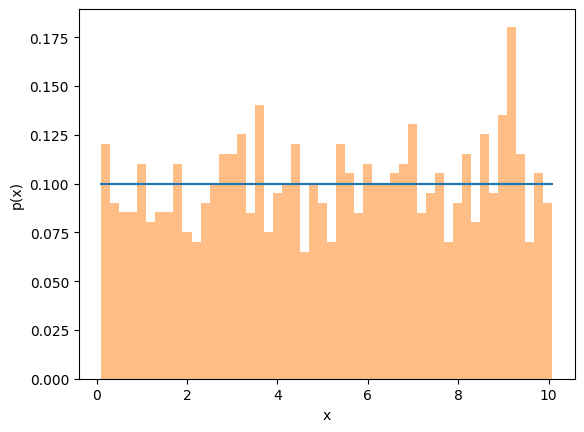

In [64]:
N = 1000
distU = stats.uniform(.1, 10)
x = distU.rvs(N) 
plt.plot(x,distU.pdf(x))
plt.hist(x, bins=50, density=True, alpha=0.5);
plt.xlabel('x')
plt.ylabel('p(x)')
plt.show()

If I increase the number of samples this will show me that I am correct in my formulation, as the sampling should converge to the uniform distribution profile. 

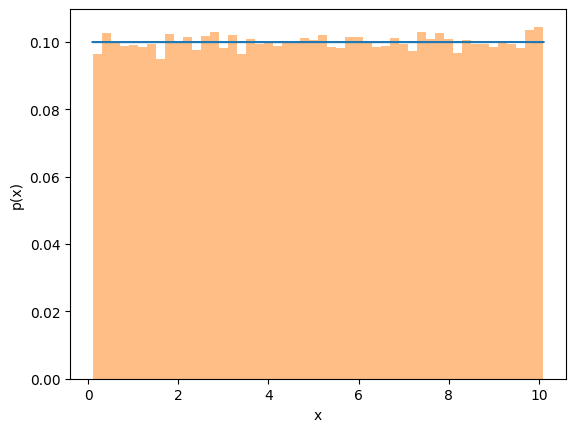

In [ ]:
N = 100000
distU = stats.uniform(.1, 10)
x1 = distU.rvs(N) 
plt.plot(x1,distU.pdf(x1))
plt.hist(x1, bins=50, density=True, alpha=0.5);
plt.xlabel('x')
plt.ylabel('p(x)')
plt.show()

Vibes.

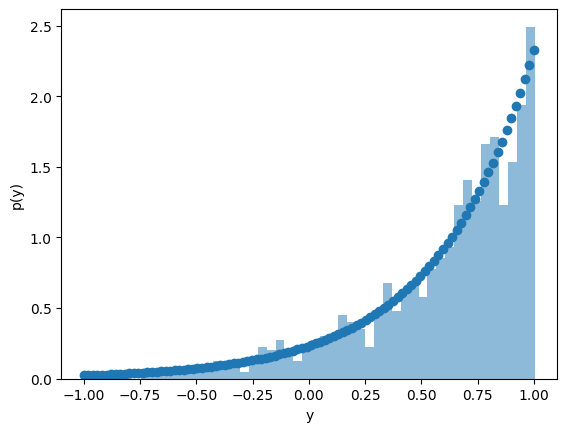

In [52]:
##3 and 4 with derivation below
y = np.log10(x);
plt.hist(y, bins=50, density=True, alpha=0.5) ;
vals = np.linspace(-1,1,100)

plt.scatter(vals,(1/9.9)*(10**vals)*np.log(10)) # this seems sketchy but it could just be a normalization issue?
plt.xlabel('y')
plt.ylabel('p(y)')
plt.show()

if y = log(x), we need to find p(y) = |dx/dy| p(x). We must find the inverse of 10^y = x. Then, dx/dy is a^y ln(a) = dx/dy 

or $(10^y ln(10))$. Then $10^y*ln(10)*0.1$ $\leftarrow$ according to the previous histogram (if I got it right) the values are unform on f(x) = (1/9.9) --> read some supplementary material on uniform distributions online. Note that the smallest value of x (.1) in p(x) translates to log(.1) or -1 in p(y).


In [ ]:
# 5 
mean_x = np.mean(x)
mean_y = np.mean(y)
print(mean_x,mean_y)
med_x = np.median(x)
med_y = np.median(y)
print(med_x,med_y)



5.055755037194047 0.5786933408305643
4.943173630260032 0.6940009043879236


<font color='red'>I think I disagree with the statement in Q4 or maybe am not interpreting it as intended. Isn't median statistics only reliable in negating the impacts of outliers? If the entire distribution (axis and profile) has changed then so should the median? </font> 

## Problem 3

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. 

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian Python object from part (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

10 random values [ 96.44963943  96.90207607 108.92341     75.30554686 115.96835698
  93.18524929  81.06901449 111.65274356  91.08050107 116.81260835]
at x=145 0.0002954565607958672


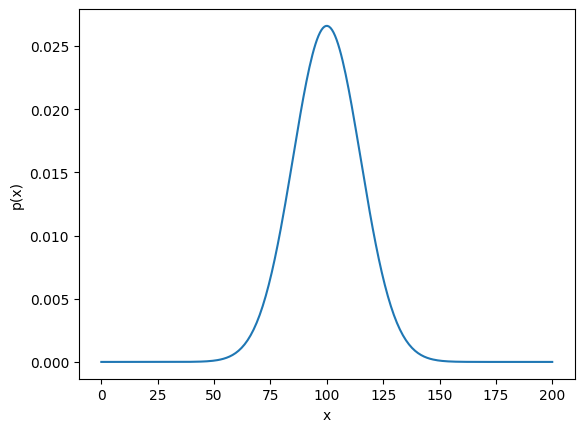

In [34]:
# 1 
IQ_Dist = stats.norm(100,15)
draws = IQ_Dist.rvs(10)
val = IQ_Dist.pdf(145)
range = np.linspace(0,200,300)
plt.plot(range, IQ_Dist.pdf(range))
plt.xlabel('x')
plt.ylabel('p(x)')
print("10 random values",draws)
print("at x=145",val)

Text(0, 0.5, 'P(x)')

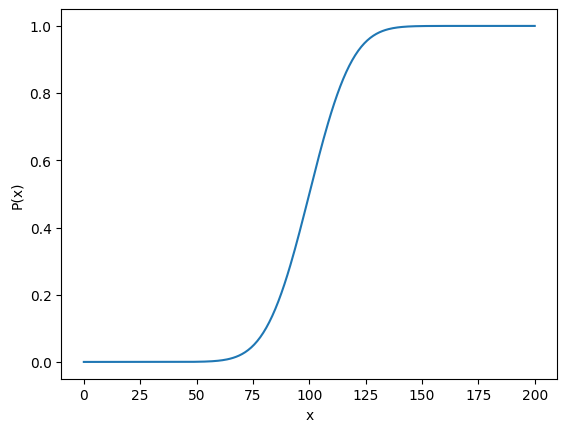

In [36]:
#2 
range = np.linspace(0,200,300)
plt.plot(range, IQ_Dist.cdf(range))
plt.xlabel('x')
plt.ylabel('P(x)')

In [70]:
#3
import math
IQ_Dist.cdf(math.inf)-IQ_Dist.cdf(145)
1 - IQ_Dist.cdf(145)

np.float64(0.0013498980316301035)

In [ ]:
#4 
IQ = IQ_Dist.ppf(1-1e-6) #um I think this makes sense
IQ2= IQ_Dist.ppf(1e-6) 
print(IQ,IQ2)
# I think this makes sense. There is an upper and lower IQ associated with 1e-6 probability 

171.3013646322563 28.69863536765652
